In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [2]:
username = "postgres"
password = "benedetta"
host = "localhost"
port = "5433"
database = "ecommerce"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

In [3]:
# testing if the database is connected to engine and pandas is running sql query.
pd.read_sql(
    "Select * From sales LIMIT 5",
    engine
)

,invoice_no,stock_code,description,quantity,unit_price,customer_id,country,invoice_day_month_year,invoice_time,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850,United Kingdom,01/12/2010,08:26,15.30
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850,United Kingdom,01/12/2010,08:26,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850,United Kingdom,01/12/2010,08:26,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850,United Kingdom,01/12/2010,08:26,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850,United Kingdom,01/12/2010,08:26,20.34


# 3. Business KPI Analysis

Key performance indicators provide an overview of the business health.

Metrics analyzed:

- Total Revenue
- Total Orders
- Total Customers
- Total Items Sold
- Average Order Value

In [5]:
kpi = pd.read_sql(
    "SELECT * FROM kpi_summary", engine
)
kpi

,total_revenue,total_orders,total_customers,total_items_sold,avg_order_value
0,8887208.89,18532,4338,5152002.0,479.56


In [6]:
kpi.T

,0
total_revenue,8887208.89
total_orders,18532.00
total_customers,4338.00
total_items_sold,5152002.00
avg_order_value,479.56


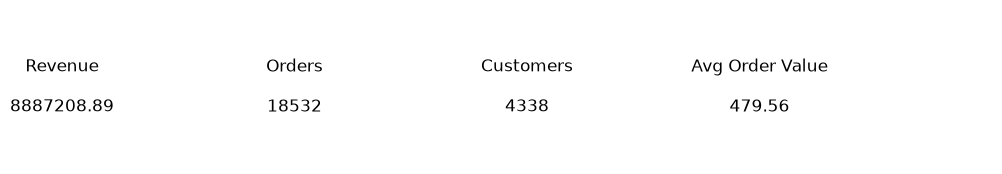

In [35]:
# creating a kpi visual card 
fig, ax = plt.subplots(figsize=(12,2))
ax.axis("off")
metrics = [
    ("Revenue", kpi["total_revenue"][0]),
    ("Orders", kpi["total_orders"][0]),
    ("Customers", kpi["total_customers"][0]),
    ("Avg Order Value", kpi["avg_order_value"][0])
]

for i,(title,value) in enumerate(metrics):

    ax.text(
        i*0.25,
        0.5,
        f"{title}\n\n{value}",
        ha="center",
        va="center",
        fontsize=12
    )

plt.show()

# 4. Sales Trend Analysis

## Monthly Revenue Trend

Business Question:

How did revenue change over time?

This helps identify:

- Growth periods
- Declining periods
- Seasonal patterns
- High-performing months

In [8]:
# Monthly Revenue Trend
monthly_revenue = pd.read_sql(
    "SELECT * FROM monthly_revenue", 
    engine
)
monthly_revenue

,month,monthly_revenue
0,2010-11-30 18:15:00+00:00,570422.73
1,2010-12-31 18:15:00+00:00,568101.31
2,2011-01-31 18:15:00+00:00,446084.92
3,2011-02-28 18:15:00+00:00,594081.76
4,2011-03-31 18:15:00+00:00,468374.33
5,2011-04-30 18:15:00+00:00,677355.15
6,2011-05-31 18:15:00+00:00,660046.05
7,2011-06-30 18:15:00+00:00,598962.90
8,2011-07-31 18:15:00+00:00,644051.04
9,2011-08-31 18:15:00+00:00,950690.20


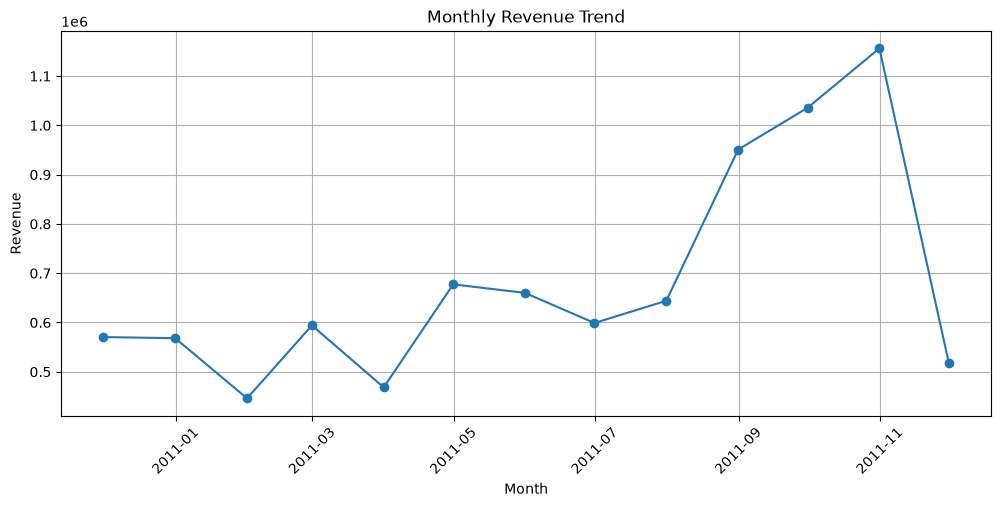

In [9]:
# line chart for monthly revenue
plt.figure(
    figsize=(12,5)
)
plt.plot(
    monthly_revenue["month"],
    monthly_revenue["monthly_revenue"],
    marker = "o" 
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.grid()
plt.show()

In [10]:
# Monthly orders Trend
monthly_orders = pd.read_sql(
    "SELECT * FROM monthly_orders", engine
)
monthly_orders

,month,total_orders
0,2010-11-30 18:15:00+00:00,1400
1,2010-12-31 18:15:00+00:00,987
2,2011-01-31 18:15:00+00:00,997
3,2011-02-28 18:15:00+00:00,1321
4,2011-03-31 18:15:00+00:00,1149
5,2011-04-30 18:15:00+00:00,1555
6,2011-05-31 18:15:00+00:00,1393
7,2011-06-30 18:15:00+00:00,1331
8,2011-07-31 18:15:00+00:00,1280
9,2011-08-31 18:15:00+00:00,1755


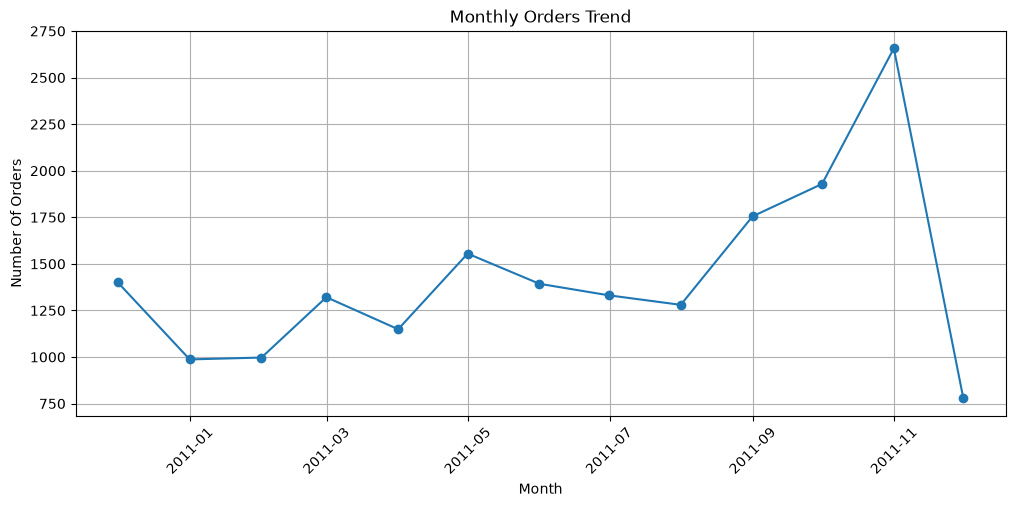

In [11]:
#line chart for monthly orders
plt.figure(figsize=(12,5))
plt.plot(
    monthly_orders["month"],
    monthly_orders["total_orders"],
    marker = "o"
)
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number Of Orders")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 5. Product Performance Analysis

This section analyzes which products contribute most to business success.

Metrics:

- Products generating highest revenue
- Products with highest sales quantity

In [12]:
# Top products by revenue
top_products_revenue = pd.read_sql(
    "SElECT * FROM top_products_revenue", engine
)
top_products_revenue


,stock_code,description,total_revenue
0,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,22423,REGENCY CAKESTAND 3 TIER,142264.75
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,85099B,JUMBO BAG RED RETROSPOT,85040.54
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POST,POSTAGE,77803.96
6,47566,PARTY BUNTING,68785.23
7,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03
8,M,Manual,53419.93
9,23084,RABBIT NIGHT LIGHT,51251.24


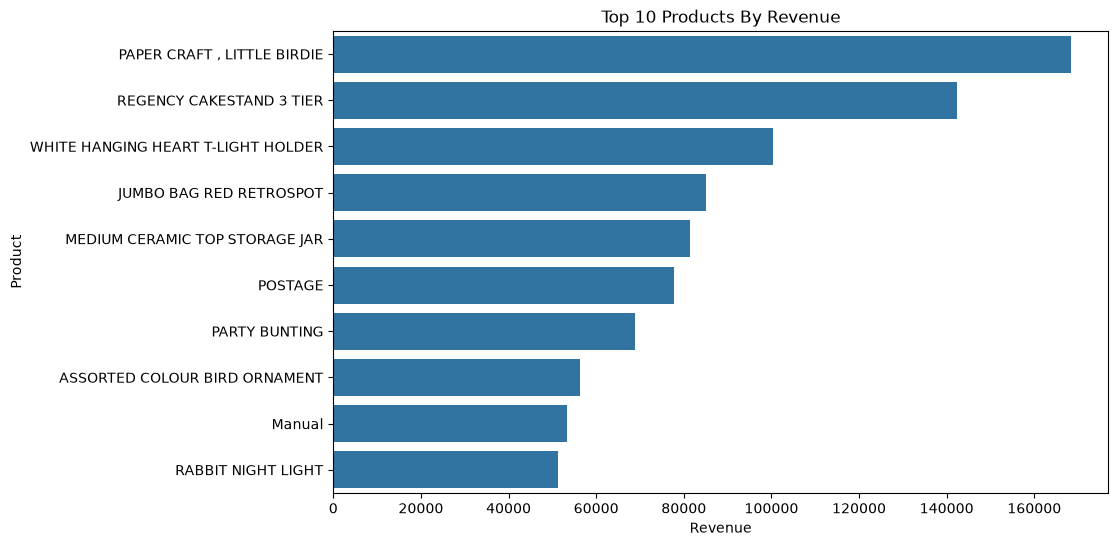

In [13]:
# bar chart for top products by revenue
plt.figure(figsize=(10,6))
sns.barplot(
    data= top_products_revenue,
    x = "total_revenue",
    y = "description"
)
plt.title("Top 10 Products By Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

In [14]:
# Top products by quantity sold
top_products_quantity = pd.read_sql(
    "SELECT * FROM top_products_quantity", engine
    )
top_products_quantity

,description,stock_code,units_sold
0,"PAPER CRAFT , LITTLE BIRDIE",23843,80995.0
1,MEDIUM CERAMIC TOP STORAGE JAR,23166,77916.0
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84077,54319.0
3,JUMBO BAG RED RETROSPOT,85099B,46078.0
4,WHITE HANGING HEART T-LIGHT HOLDER,85123A,36706.0
5,ASSORTED COLOUR BIRD ORNAMENT,84879,35263.0
6,PACK OF 72 RETROSPOT CAKE CASES,21212,33670.0
7,POPCORN HOLDER,22197,30919.0
8,RABBIT NIGHT LIGHT,23084,27153.0
9,MINI PAINT SET VINTAGE,22492,26076.0


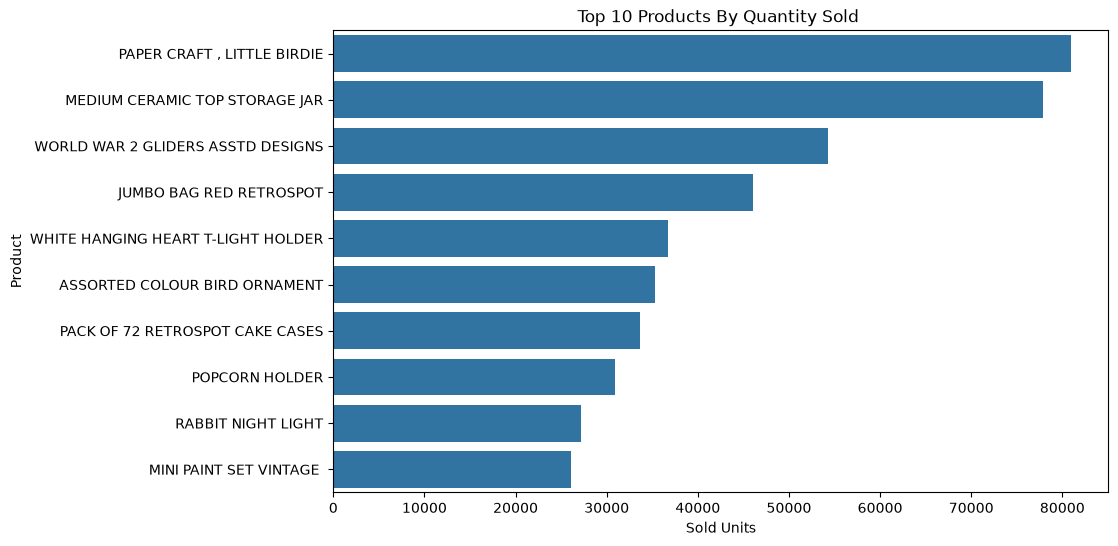

In [15]:
# Bar chart for top products by its sold unit
plt.figure(figsize=(10,6))
sns.barplot(
    data = top_products_quantity,
    x="units_sold",
    y="description" 
)
plt.title("Top 10 Products By Quantity Sold ")
plt.xlabel("Sold Units")
plt.ylabel("Product")
plt.show()

# 6. Customer Behavior Analysis

Understanding customers helps businesses improve retention and marketing strategies.

Analysis performed:

- Top spending customers
- Repeat customers
- One-time customers
- RFM customer segmentation

In [16]:
# highest value customers
top_customers = pd.read_sql(
    "SELECT * FROM top_customers", engine
)
top_customers

,customer_id,total_spent
0,14646,280206.02
1,18102,259657.30
2,17450,194390.79
3,16446,168472.50
4,14911,143711.17
5,12415,124914.53
6,14156,117210.08
7,17511,91062.38
8,16029,80850.84
9,12346,77183.60


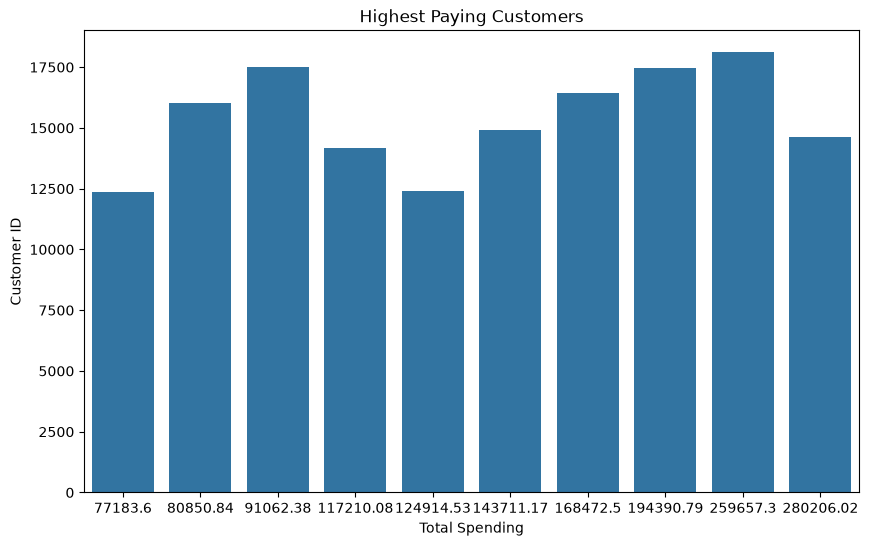

In [17]:
# bar chart for highest value customers
plt.figure(figsize=(10,6))
sns.barplot(
    data = top_customers,
    x= "total_spent",
    y= "customer_id"
)
plt.title("Highest Paying Customers")
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")
plt.show()


In [18]:
# customer segmentaion by RFM
rfm_segments = pd.read_sql(  
    "SELECT *FROM rfm_segments" , engine
)
rfm_segments


,customer_id,r_score,f_score,m_score,customer_segment
0,12791,1,1,1,Regular Customers
1,15165,1,2,3,Regular Customers
2,13747,1,1,1,Regular Customers
3,17643,1,1,1,Regular Customers
4,18074,1,2,3,Regular Customers
...,...,...,...,...,...
4333,12433,5,5,5,Champions
4334,16954,5,5,5,Champions
4335,17490,5,5,5,Champions
4336,17364,5,5,5,Champions


## RFM Segmentation

RFM analysis groups customers based on purchasing behavior.

### Recency
How recently a customer purchased.

### Frequency
How often a customer purchases.

### Monetary
How much money a customer spends.

Customer groups:

- Champions
- Loyal Customers
- Big Spenders
- At Risk
- Regular Customers

In [19]:
#count of each number of customer segments
segment_count = (
    rfm_segments["customer_segment"].value_counts()
)
segment_count

customer_segment
Regular Customers    1979
Champions             947
Loyal Customers       787
Big Spenders          355
At Risk               270
Name: count, dtype: int64

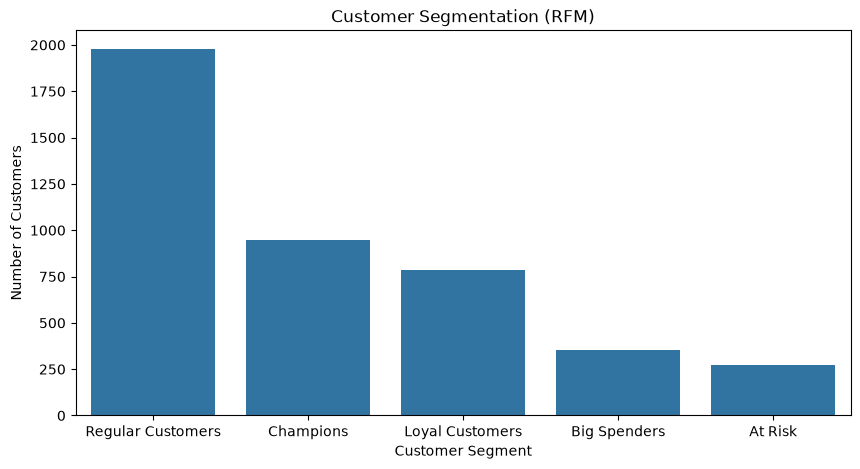

In [20]:
# bar chart for customer segmentation
plt.figure(figsize=(10,5))
sns.barplot(
    x=segment_count.index,
    y=segment_count.values
)
plt.title("Customer Segmentation (RFM)")


plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

In [21]:
# one time customer and repeated customer
customer_retention = pd.read_sql(
    "SELECT * FROM customer_retention", engine
)
customer_retention


,customer_type,customers
0,One-Time Customers,1493
1,Repeated Customers,2845


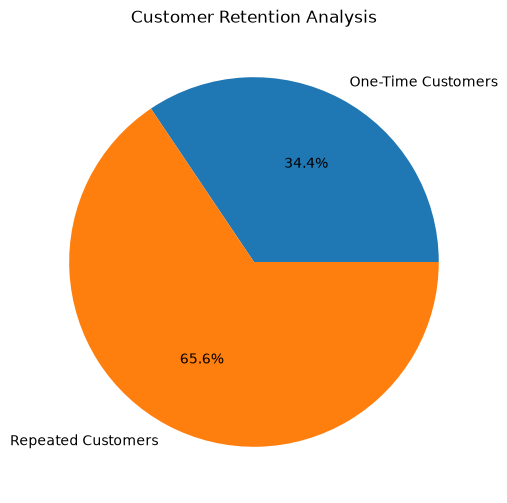

In [22]:
# pie chart for one time and repeated customers
plt.figure(figsize=(6,6))

plt.pie(
    customer_retention["customers"],
    labels=customer_retention["customer_type"],
    autopct= "%1.1f%%"
)

plt.title("Customer Retention Analysis")
plt.show()


# 7. Geographic Analysis

This analysis identifies important markets.

Questions answered:

- Which countries generate the most revenue?
- Which countries have the highest order volume?

In [23]:
# revenue by country
country_revenue = pd.read_sql(
"SELECT * FROM country_revenue LIMIT 10",
engine
)
country_revenue

,country,total_revenue
0,United Kingdom,7285024.64
1,Netherlands,285446.34
2,EIRE,265262.46
3,Germany,228678.40
4,France,208934.31
5,Australia,138453.81
6,Spain,61558.56
7,Switzerland,56443.95
8,Belgium,41196.34
9,Sweden,38367.83


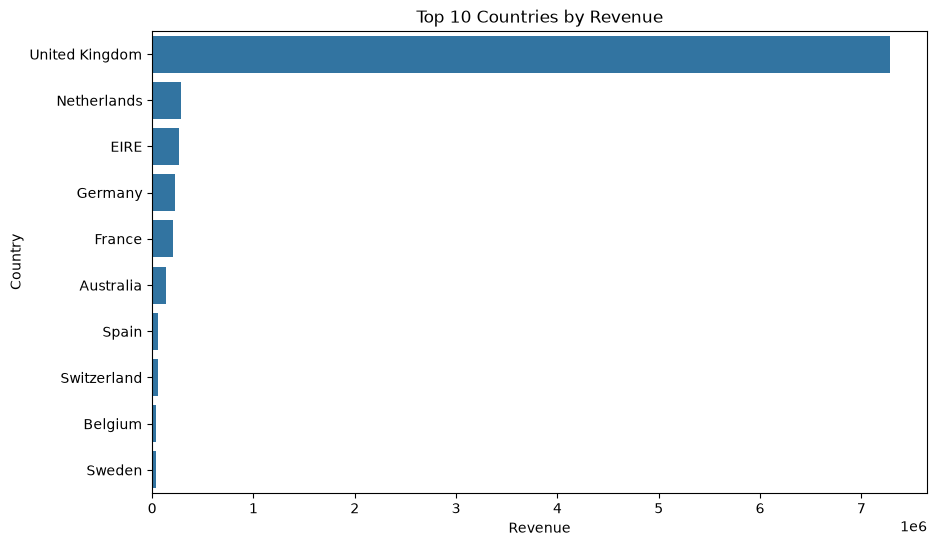

In [24]:
# bar chart for revenue by country
plt.figure(figsize=(10,6))
sns.barplot(
    data=country_revenue,
    x="total_revenue",
    y="country"
)

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

In [26]:
# orders by country
country_orders = pd.read_sql(
"SELECT * FROM country_orders LIMIT 10",
engine
)
country_orders

,country,total_orders
0,United Kingdom,16646
1,Germany,457
2,France,389
3,EIRE,260
4,Belgium,98
5,Netherlands,94
6,Spain,90
7,Portugal,57
8,Australia,57
9,Switzerland,51


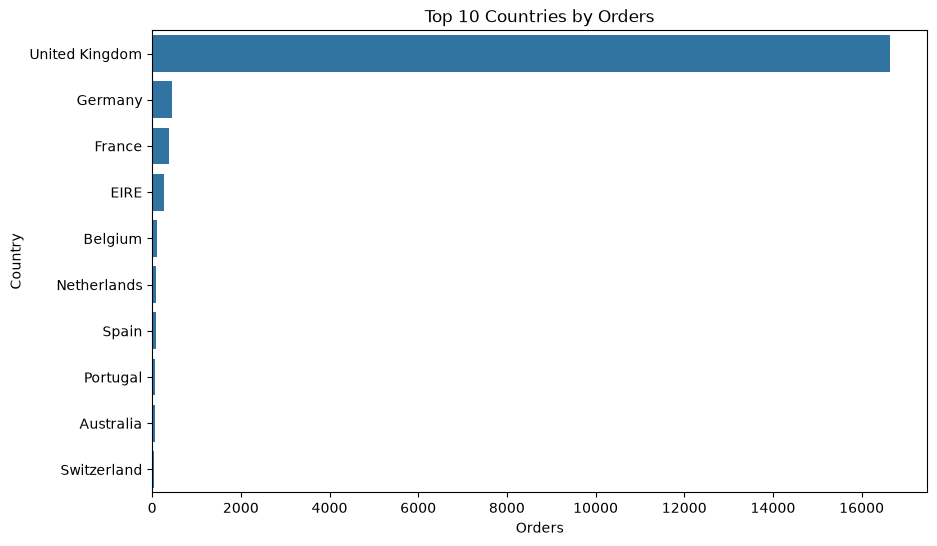

In [28]:
# bar chart for orders by country
plt.figure(figsize=(10,6))
sns.barplot(
    data=country_orders,
    x="total_orders",
    y="country"
)

plt.title("Top 10 Countries by Orders")
plt.xlabel("Orders")
plt.ylabel("Country")

plt.show()

# 8. Revenue Concentration Analysis

Pareto analysis follows the 80/20 principle.

The goal is to identify whether a small number of products contribute most of the revenue.

Business usage:

- Prioritize important products
- Optimize inventory
- Focus marketing efforts

In [29]:
# does 20% of products generate 80% revenue
product_pareto = pd.read_sql(
    "SELECT * FROM product_pareto", engine
)
product_pareto


,description,revenue,cumulative_percentage
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,1.90
1,REGENCY CAKESTAND 3 TIER,142264.75,3.50
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,4.63
3,JUMBO BAG RED RETROSPOT,85040.54,5.58
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,6.50
...,...,...,...
3872,PURPLE FRANGIPANI HAIRCLIP,0.85,100.00
3873,VINTAGE BLUE TINSEL REEL,0.84,100.00
3874,SET 12 COLOURING PENCILS DOILEY,0.65,100.00
3875,HEN HOUSE W CHICK IN NEST,0.42,100.00


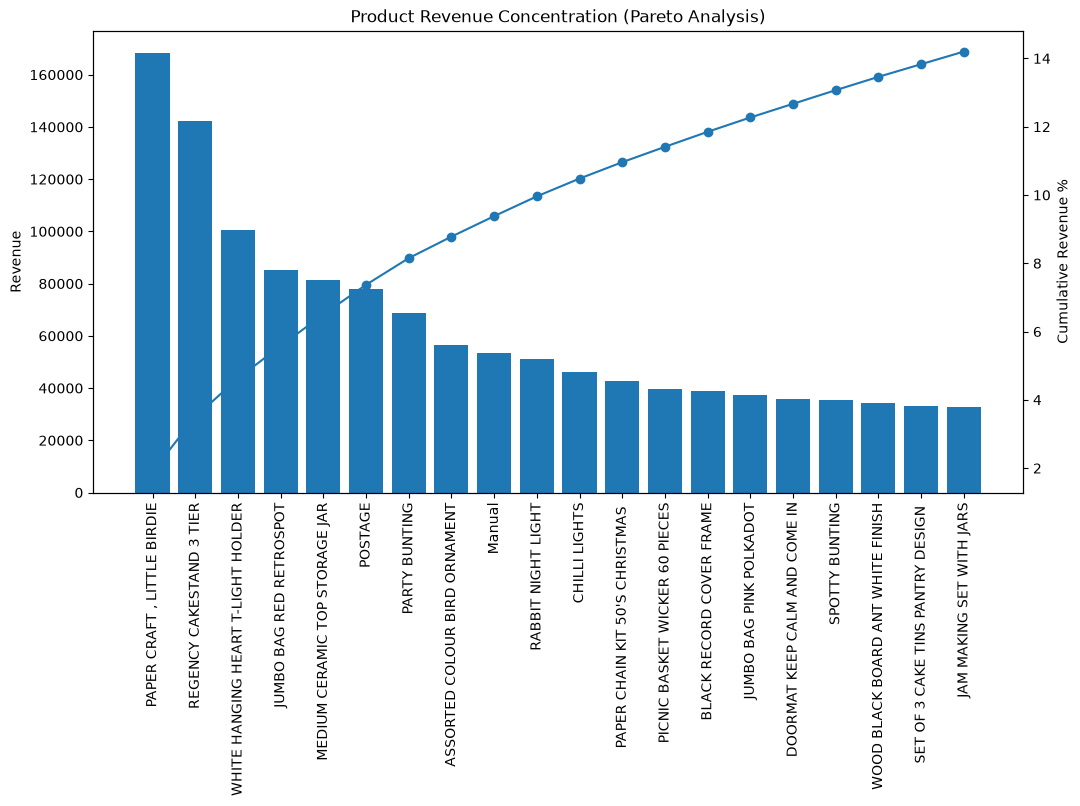

In [30]:
#line chart for product pareto
fig, ax1 = plt.subplots(figsize=(12,6))
# Revenue bars
ax1.bar(
    product_pareto["description"].head(20),
    product_pareto["revenue"].head(20)
)

ax1.set_ylabel("Revenue")

ax1.tick_params(
    axis="x",
    rotation=90
)

# Cumulative percentage line
ax2 = ax1.twinx()
ax2.plot(
    product_pareto["description"].head(20),
    product_pareto["cumulative_percentage"].head(20),
    marker="o"
)
ax2.set_ylabel("Cumulative Revenue %")

plt.title(
"Product Revenue Concentration (Pareto Analysis)"
)


plt.show()

# Conclusion

This project analyzed e-commerce sales data using Python, PostgreSQL, and visualization libraries.

Key areas covered:

- Data cleaning
- Revenue analysis
- Product performance
- Customer segmentation
- Sales trends
- Market analysis

The insights generated can help businesses improve:

- Customer retention
- Inventory planning
- Marketing decisions
- Revenue growth strategies